In [1]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
from sklearn.model_selection import train_test_split;
from sklearn.preprocessing import StandardScaler;
from sklearn.linear_model import LogisticRegression;
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis;
from sklearn.metrics import confusion_matrix,f1_score,accuracy_score,precision_score,recall_score,roc_curve,auc,roc_auc_score;

In [2]:
df = pd.read_csv('diabetes.csv');
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
rows, cols = df.shape;
print(f'The dataset has {rows} rows and {cols} columns.');

The dataset has 768 rows and 9 columns.


In [9]:
X = df.loc[:, df.columns != 'Outcome'];
y = df['Outcome'];
X = StandardScaler().fit_transform(X);

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42);

In [10]:
log_reg = LogisticRegression()
lda = LinearDiscriminantAnalysis()

In [11]:
log_reg.fit(X_train, y_train);
lda.fit(X_train, y_train);

y_pred_log_reg = log_reg.predict(X_test);
y_pred_lda = lda.predict(X_test);

In [12]:
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg);
print("Confusion Matrix for Logistic Regression:\n", cm_log_reg);

Confusion Matrix for Logistic Regression:
 [[79 20]
 [18 37]]


In [13]:
cm_lda = confusion_matrix(y_test, y_pred_lda);
print("Confusion Matrix for LDA:\n", cm_lda);

Confusion Matrix for LDA:
 [[80 19]
 [18 37]]


In [14]:
log_acc = round(accuracy_score(y_test, y_pred_log_reg)*100, 2);
log_recall = round(recall_score(y_test, y_pred_log_reg),2)
log_precision = round(precision_score(y_test, y_pred_log_reg),2);
log_f1 = round(f1_score(y_test, y_pred_log_reg),2);

lda_acc = round(accuracy_score(y_test, y_pred_lda)*100, 2);
lda_recall = round(recall_score(y_test, y_pred_lda),2);
lda_precision = round(precision_score(y_test, y_pred_lda),2);
lda_f1 = round(f1_score(y_test, y_pred_lda),2);

print("Logistic regression\n");
print("Accuracy:", log_acc, "Recall:", log_recall, "Precision:", log_precision, "F1 Score:", log_f1);

print("LDA\n");
print("Accuracy:", lda_acc, "Recall:", lda_recall, "Precision:", lda_precision, "F1 Score:", lda_f1);

Logistic regression

Accuracy: 75.32 Recall: 0.67 Precision: 0.65 F1 Score: 0.66
LDA

Accuracy: 75.97 Recall: 0.67 Precision: 0.66 F1 Score: 0.67


In [15]:
y_pred_log_reg = log_reg.predict_proba(X_test)[:, 1];
y_pred_lda = lda.predict_proba(X_test)[:, 1];

In [16]:
roc = pd.DataFrame({
    'True': y_test,
    'Logistic Regression': y_pred_log_reg,
    'LDA': y_pred_lda
});

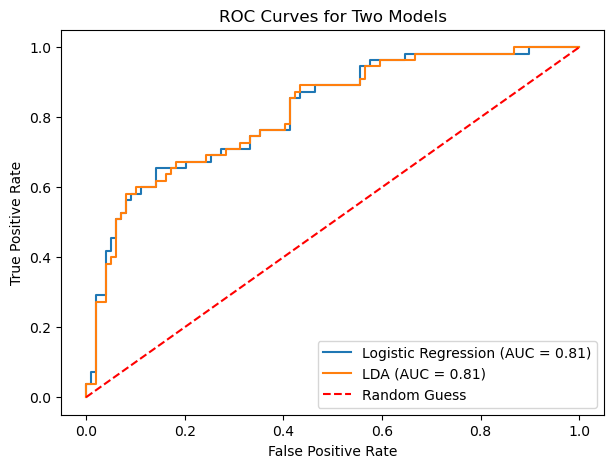

In [17]:
plt.figure(figsize=(7, 5))
models = ['Logistic Regression', 'LDA'];
for model in models:
    fpr, tpr, _ = roc_curve(roc['True'], roc[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Two Models')
plt.legend()
plt.show()

In [18]:
roc_auc_log_reg = roc_auc_score(y_test, y_pred_log_reg)
print(f'ROC AUC Score for Logistic Regression: {roc_auc_log_reg:.2f}')

roc_auc_lda = roc_auc_score(y_test, y_pred_lda)
print(f'ROC AUC Score for LDA: {roc_auc_lda:.2f}')


ROC AUC Score for Logistic Regression: 0.81
ROC AUC Score for LDA: 0.81


In [19]:
print("Coefficients for Logistic Regression:\n");
print("Coefficients:", log_reg.coef_);
print(np.argsort(log_reg.coef_));
print("Most siginificant predictor:",df.columns[np.argsort(log_reg.coef_)[0][-1]],"\nLeast significant predictor:", df.columns[np.argsort(log_reg.coef_)[0][0]]);

print("\n------------------###################------------------");

print("\nCoefficients for LDA:\n");
print("Coefficients:", lda.coef_);
print(np.argsort(lda.coef_));
print(df.columns[np.argsort(lda.coef_)[0][-1]] , df.columns[np.argsort(lda.coef_)[0][0]]);
print("Most siginificant predictor:",df.columns[np.argsort(lda.coef_)[0][-1]],"\nLeast significant predictor:", df.columns[np.argsort(lda.coef_)[0][0]]);

Coefficients for Logistic Regression:

Coefficients: [[ 0.21624195  1.06932996 -0.25867641  0.04720329 -0.19899822  0.79237086
   0.22709403  0.43036184]]
[[2 4 3 0 6 7 5 1]]
Most siginificant predictor: Glucose 
Least significant predictor: BloodPressure

------------------###################------------------

Coefficients for LDA:

Coefficients: [[ 0.22316102  1.13954219 -0.27932765  0.05370078 -0.20279696  0.75012853
   0.23322761  0.48066002]]
[[2 4 3 0 6 7 5 1]]
Glucose BloodPressure
Most siginificant predictor: Glucose 
Least significant predictor: BloodPressure
